In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_validate, GridSearchCV

# Diamond Price Prediction — Model Development & Selection

This project uses the Seaborn **Diamonds** dataset (~54,000 records) to build and compare regression models for predicting diamond price. It consolidates exploratory data analysis (EDA) from a prior assignment with a full model development and hyperparameter tuning pipeline.

---

## Pipeline Overview

**1. Exploratory Data Analysis**
Investigated feature distributions, skewness, missing/zero values, and multicollinearity across categorical (`cut`, `color`, `clarity`) and numerical (`carat`, `depth`, `table`, `x`, `y`, `z`) features. Strong linear correlations were identified between `carat` and `price` (r ≈ 0.92), as well as among the dimensional features `x`, `y`, and `z`.

**2. Data Preparation**
- Imputed zero values in `z` using the depth formula: `z = depth% × mean(x, y)`
- Removed physically implausible dimensional outliers (values outside 1–11 mm)
- Dropped duplicate records, yielding a clean dataset of 53,784 rows
- Split into training (80%) and testing (20%) sets with a fixed random state
- Encoded categorical features via two strategies:
  - **Ordinal Encoding** — preserves assumed hierarchical ranking (e.g., Fair < Good < Ideal)
  - **One-Hot Encoding** — treats each label as independent, nominal
- Standardized numerical features using `StandardScaler`

**3. Baseline Model Evaluation**
Evaluated four regressors — `LinearRegression`, `Lasso`, `Ridge`, and `DecisionTreeRegressor` — using 5-fold cross-validation (RMSE and MAE) under default hyperparameters across both encoding schemes.

**4. Hyperparameter Tuning**
Applied `GridSearchCV` to identify optimal regularization strength (`alpha`) for Lasso and Ridge, and optimal tree depth (`max_depth`, `min_samples_leaf`) for the Decision Tree, independently across both encoding methods.

**5. Model Selection**
Compared 14 model configurations by mean cross-validation RMSE. The **Decision Tree with ordinal encoding and tuned `min_samples_leaf`** emerged as the champion model (RMSE ≈ 624), outperforming all linear regressors and demonstrating the non-linear structure of the data.

# Load dataset

In [3]:
df = sns.load_dataset('diamonds')
df.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


In [4]:
# distinguishing lists of categorical vs. numerical features

categorical_features = df.select_dtypes(include='category').columns
numerical_features = df.select_dtypes(include='number').columns.drop('price')

# Data Visualization

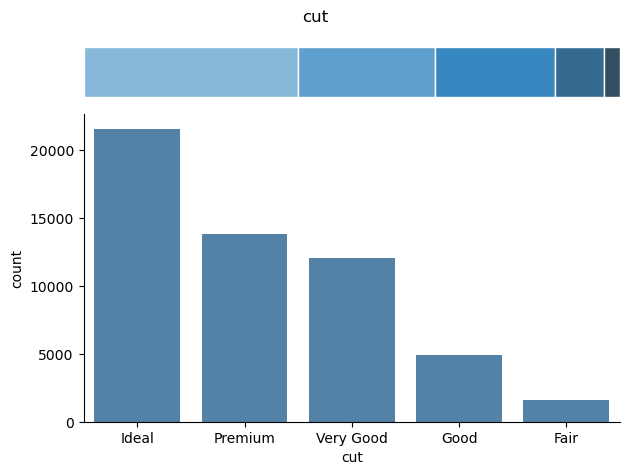

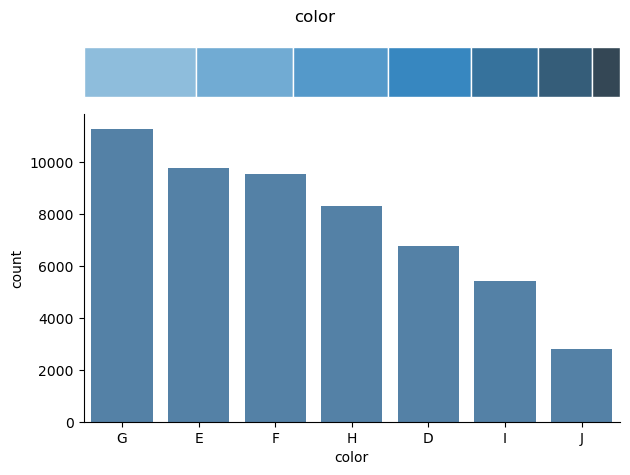

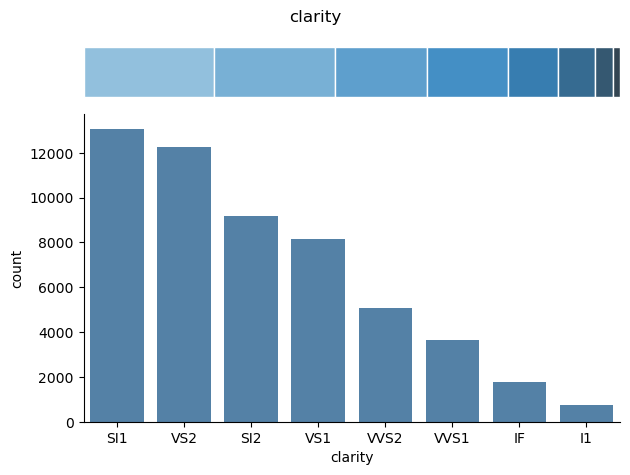

In [ ]:
for feature in categorical_features:
    value_counts = df[feature].value_counts()
    proportions = value_counts / value_counts.sum()

    fig, (ax_top, ax_bar) = plt.subplots(nrows=2, gridspec_kw={'height_ratios': (.15, .85)})

    # top: stacked horizontal bar showing proportional breakdown across categories
    left = 0
    palette = sns.color_palette('Blues_d', len(proportions))
    for (label, prop), color in zip(proportions.items(), palette):
        ax_top.barh(0, prop, left=left, color=color, edgecolor='white', height=0.5)
        left += prop
    ax_top.set(yticks=[], xticks=[], xlim=(0, 1))
    sns.despine(ax=ax_top, left=True, bottom=True)

    # bottom: countplot ordered by frequency
    sns.countplot(data=df, x=feature, ax=ax_bar, order=value_counts.index, color='steelblue')
    sns.despine(ax=ax_bar)

    fig.suptitle(feature)
    plt.tight_layout()
    plt.show()

## Interpretation of categorical features

The *cut* feature is classified into five unique categories: ideal, premium, very good, good, and fair. The distribution is heavily skewed toward higher grade. Of the sample, ideal reflects the highest frequency, with more than 21551 diamonds being of an ideal cut. Fair represents the lowest, with about 1500 diamonds being of a fair cut.

The *color* feature is classified into seven unique categories: D,E,F,G,H,I,J. The distribution is fairly normal, with 11292 diamonds being of a G color grade. Notably, the G grade is the most frequently-occuring. J (the lowest color grade) is the least common.

The *clarity* feature is classified into eight unique categories: IF, VVS1, VVS2, VS1, VS2, SI1, SI2, I1. Of the dataset, 13065 diamonds are of an SI1 clarity grade (the most commmon), with approximately 1000 diamonds being of an I1 clarity grade (the lowest quality as well as the least common). 

### Skew, Box plots, and histograms for Numerical Features (Step 1(f)(vii) skew included)

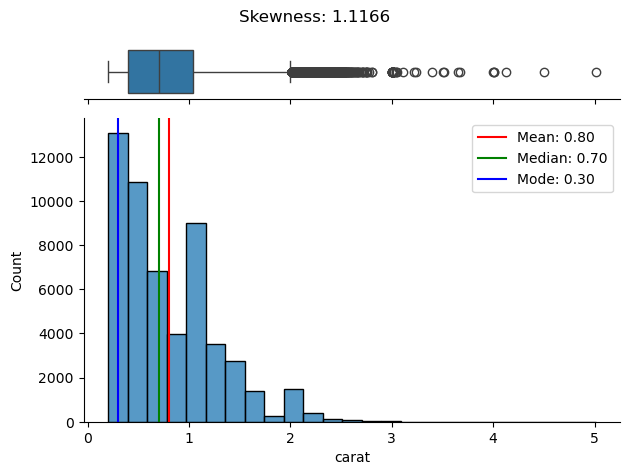

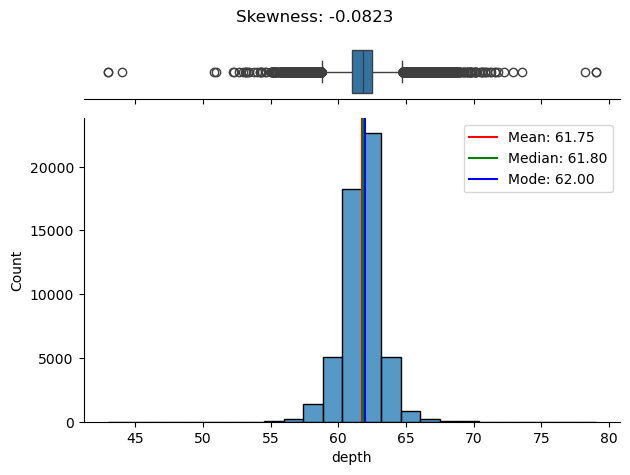

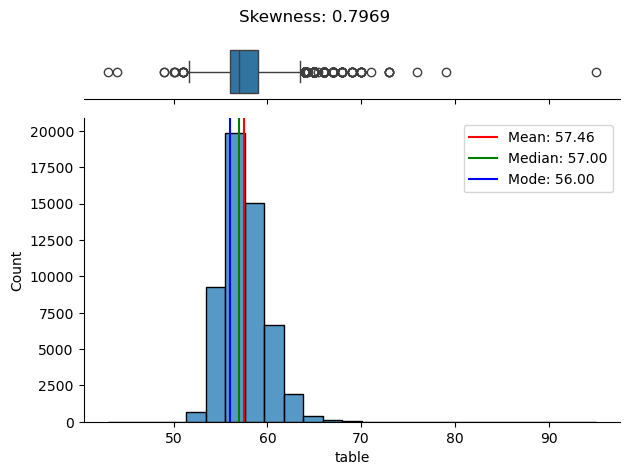

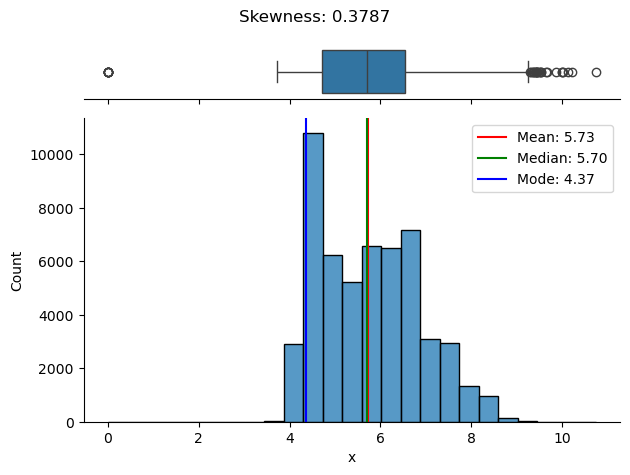

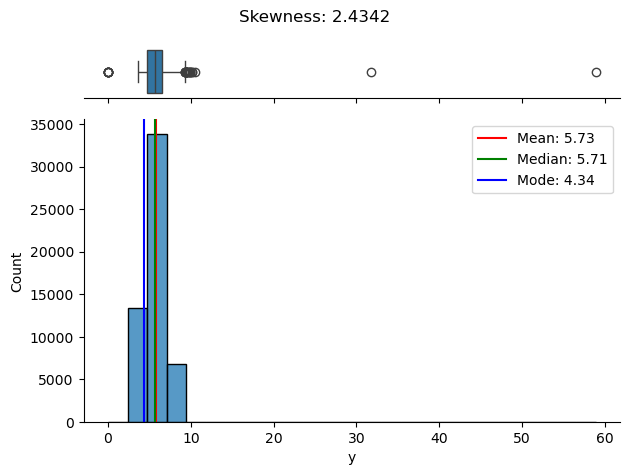

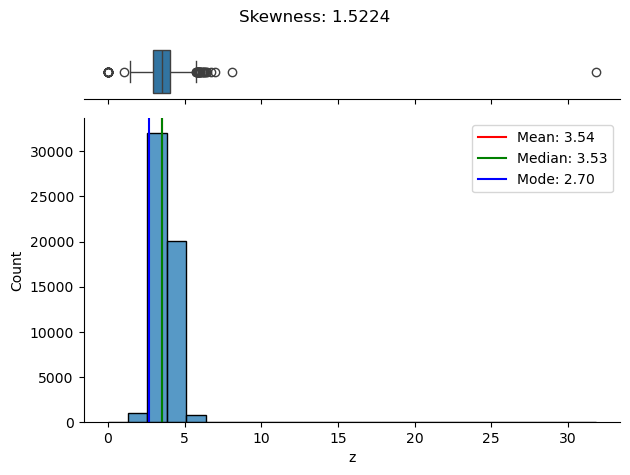

In [ ]:
for feature in numerical_features:

    mean = df[feature].mean()
    median =  df[feature].median()
    mode = df[feature].mode()

    fig, (ax_box, ax_hist) = plt.subplots(nrows= 2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})
    sns.boxplot(data= df, x= feature, ax= ax_box, orient= 'h')
    sns.histplot(data= df, x= feature, ax= ax_hist, bins= 25)

    ax_hist.axvline(mean, color='red', linestyle='-', label=f'Mean: {mean:.2f}')
    ax_hist.axvline(median, color='green', linestyle='-', label=f'Median: {median:.2f}')
    ax_hist.axvline(mode[0], color='blue', linestyle='-', label=f'Mode: {mode[0]:.2f}')

    ax_hist.legend()

    ax_box.set(yticks=[])
    fig.suptitle(f'Skewness: {np.round(df[feature].skew(), 4)}')
    sns.despine(ax=ax_hist)
    sns.despine(ax=ax_box, left=True)
    plt.tight_layout()

## Skew, Box plots, and histograms for Numerical Features

Regarding skew, each numerical feature is affected by outliers, as depicted in the boxplots. Features 'y' (width) and 'z' (depth) show the highest skew values (2.4342, 1.5224 respectively).

As discussed, the presence of the rarer, larger diamonds contributes to a larger, positive skew value (1.1166) for the carat feature.  

Though negative, the slight skewness of the depth feature is close to zero (-0.0823) showing that there are a few gems with considerably shallower depth. 

As shown on the x-plots, most of the diamonds cluster between ~4-8mm in length, with an average of 5.73mm. The 'x' skew value (0.3787) shows that a few gems pull the tail slightly to the right. 

Regarding the width ('y'), most of the diamonds cluster between 3-10mm, with a significant portion of the gems recorded around 7mm in width. The average diamond width is 5.73mm. However, there is an outlier (the presumed data entry error of 58.9) which pulls the tail strongly to the right and contributes to a strong positive skew value (2.4342). 

Finally, the depth ('z') feature shows a skew value of 1.5224, which alludes to the presence of the outlier. Most of the gems cluster between ~2-5mm, with an average depth of 3.54mm. Each of these features is also impacted by the presence of zero-values, which would contribute to short tails to the left of the distributions. 

# Correlations between all Numerical Input Features and Target: Price

In [ ]:
correlation_with_price = df[numerical_features].corrwith(df['price'])

correlation_with_price

carat    0.921591
depth   -0.010647
table    0.127134
x        0.884435
y        0.865421
z        0.861249
dtype: float64

## Interpretation of numerical feature correlations

Carat is strongly correlated with price, showing the largest correlation value (0.9216). This makes sense given that length, width, and depth contribute to size, which contributes to weight (carat). The greater the quantity, the greater the weight. Thus, a higher quantity of a more scarce resource (diamonds) will demand a higher price. 

The dimensional features x, y, and z also show strong positive correlations (~0.86–0.88), which is expected since larger physical dimensions directly contribute to a diamond's carat weight. Depth and table show near-zero or weak correlations with price (-0.01 and 0.13, respectively), suggesting that these ratio-based quality metrics have minimal direct linear influence on price by themselves. These findings agree with intuition: a diamond's size and weight drive price far more than its proportional geometry.

In [ ]:
input_feature_correlation = df[numerical_features].corr()

correlation_pairs = input_feature_correlation.stack().reset_index()
correlation_pairs.columns = ['feature_1', 'feature_2', 'correlation']

correlation_pairs = correlation_pairs[correlation_pairs['feature_2'] > correlation_pairs['feature_1']]

correlation_pairs = correlation_pairs.loc[correlation_pairs['correlation'].abs().sort_values(ascending=False).index]

correlation_pairs

,feature_1,feature_2,correlation
3,carat,x,0.975094
22,x,y,0.974701
23,x,z,0.970772
5,carat,z,0.953387
29,y,z,0.952006
4,carat,y,0.951722
8,depth,table,-0.295779
15,table,x,0.195344
16,table,y,0.183760
2,carat,table,0.181618


In [ ]:
correlation_pairs[correlation_pairs['correlation'].abs() > 0.8]

,feature_1,feature_2,correlation
3,carat,x,0.975094
22,x,y,0.974701
23,x,z,0.970772
5,carat,z,0.953387
29,y,z,0.952006
4,carat,y,0.951722


### Summary of numerical feature exploration

As shown, the dimensional metrics are all strongly correlated with each other; in fact, the correlation coefficients are almost identical between the three feature pairings. Each gem's carat feature can be linearly predicted from its dimensions, which suggests high multicollinearity. 

Vital next steps:
- Imputation of the zero values to allow for more accurate interpretation of the skewness and correlation values
- Dropping the dimensional features to improve coefficient interpretability
- Removal of duplicate rows
- Encode the categorical features (cut, color, clarity) into numerical representations
- Standardize the numerical features so they share a common scale

# Data Preparation

## Handling Zero values

In [ ]:
# filter and remove zeros 
zero_count = (df[['x','y','z']] == 0).sum(axis=1)
df = df[zero_count <= 1]


print(f'Zero-values dropped...Rows remaining: {df.shape[0]} | Columns remaining: {df.shape[1]}') # verification

Zero-values dropped...Rows remaining: 53932 | Columns remaining: 10


# Imputation of 'z' values 

In [ ]:
# depth = z/(average of x and y)

z_imputed = (df['depth'] / 100) * ((df['x'] + df['y']) / 2)

df['z'] = np.where(df['z'] == 0, z_imputed, df['z'])

df.shape # verification

(53932, 10)

# Removal of values outside range of 1, 11 in x, y, z columns

In [ ]:
# removing out-of-bound values to minimize skew of data
df = df[(df['x'].between(1, 11) & df['y'].between(1, 11) & df['z'].between(1, 11))]

df.shape # verification

(53929, 10)

# Dropping duplicates

In [ ]:
# dropping duplicates for data accuracy, to reduce overfitting

df = df.drop_duplicates()

df.shape # verification

(53784, 10)

# Data Partitioning

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['price']), 
                                                    df['price'],
                                                    test_size=.20,
                                                    random_state=415)

# Ordinal Encoding

In [ ]:
#categorical feature labels (best to worst)
cut_labels = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'] 

color_labels = ['J', 'I', 'H', 'G', 'F', 'E', 'D']

clarity_labels = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

categories = [cut_labels, color_labels, clarity_labels]

ordinal_transformer = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(categories=categories), categorical_features),
    ('scaler', StandardScaler(), numerical_features)
])

X_train_ordenc = ordinal_transformer.fit_transform(X_train)
X_test_ordenc = ordinal_transformer.transform(X_test)

print(f'X_train_ordenc shape: {X_train_ordenc.shape}')
print(f'X_test_ordenc shape: {X_test_ordenc.shape}')

pd.DataFrame(X_train_ordenc).describe().T

X_train_ordenc shape: (43027, 9)
X_test_ordenc shape: (10757, 9)


,count,mean,std,min,25%,50%,75%,max
0,43027.0,2.904943e+00,1.114606,0.000000,2.000000,3.000000,4.000000,4.000000
1,43027.0,3.407767e+00,1.700189,0.000000,2.000000,3.000000,5.000000,6.000000
2,43027.0,3.048760e+00,1.643673,0.000000,2.000000,3.000000,4.000000,7.000000
3,43027.0,-1.486249e-17,1.000012,-1.261780,-0.838720,-0.204130,0.515073,7.834013
4,43027.0,-6.900738e-16,1.000012,-12.443541,-0.520389,0.040701,0.531654,12.104126
5,43027.0,-1.534139e-15,1.000012,-6.477808,-0.655837,-0.207993,0.687695,9.644574
6,43027.0,5.271231e-16,1.000012,-1.788528,-0.911932,-0.035336,0.724977,4.025631
7,43027.0,5.317470e-17,1.000012,-1.821363,-0.911308,-0.019273,0.719584,3.990376
8,43027.0,4.921136e-17,1.000012,-3.575536,-0.909333,-0.025428,0.713574,4.611448


# One Hot Encoding

In [ ]:
ohe_transformer = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(sparse_output=False, drop='first'), categorical_features),
    ('scaler', StandardScaler(),                              numerical_features)])

X_train_oheenc = ohe_transformer.fit_transform(X_train)
X_test_oheenc = ohe_transformer.transform(X_test)

print(f'X_train_one_hot shape: {X_train_oheenc.shape}')
print(f'X_test_one_hot shape: {X_test_oheenc.shape}')

pd.DataFrame(X_train_oheenc).describe().T

X_train_one_hot shape: (43027, 23)
X_test_one_hot shape: (10757, 23)


,count,mean,std,min,25%,50%,75%,max
0,43027.0,9.015269e-02,0.286404,0.000000,0.000000,0.000000,0.000000,1.000000
1,43027.0,3.990982e-01,0.489719,0.000000,0.000000,0.000000,1.000000,1.000000
2,43027.0,2.561647e-01,0.436519,0.000000,0.000000,0.000000,1.000000,1.000000
3,43027.0,2.249518e-01,0.417555,0.000000,0.000000,0.000000,0.000000,1.000000
4,43027.0,1.823739e-01,0.386157,0.000000,0.000000,0.000000,0.000000,1.000000
5,43027.0,1.765636e-01,0.381303,0.000000,0.000000,0.000000,0.000000,1.000000
6,43027.0,2.096358e-01,0.407053,0.000000,0.000000,0.000000,0.000000,1.000000
7,43027.0,1.536245e-01,0.360593,0.000000,0.000000,0.000000,0.000000,1.000000
8,43027.0,1.006112e-01,0.300817,0.000000,0.000000,0.000000,0.000000,1.000000
9,43027.0,5.171172e-02,0.221447,0.000000,0.000000,0.000000,0.000000,1.000000


# Models with Default Hyperparameter Settings

## Instantiating Regressors (LinearRegression, Lasso, Ridge, and DecisionTree)

In [ ]:
# building list of algorithms for seamless construction
list_of_algos = [
    (LinearRegression, {}),
    (Lasso, {'max_iter': 100000}),
    (Ridge, {'max_iter': 100000}),
    (DecisionTreeRegressor, {'random_state': 415})
]

model_list = [algo(**params) for algo, params in list_of_algos] # list comprehension to instantiate algorithms reduce time complexity
linear_regressor, lasso_regressor, ridge_regressor, decision_tree_regressor = model_list

# Ordinal Encoded Cross-Validation Scores

In [ ]:
final_metrics = [] # empty list that will populate with mean scores for part 4

def cross_validation(encoded_training_data, k_fold_param, encoding_method):
    '''Cross validates regressor models using K-fold cross validation'''
    metrics = []

    for model in model_list:
        name = f' {model.__class__.__name__} Default'
        print(f'Cross Validation for {name}')

        # cross validation score calculations
        cv_results = cross_validate(estimator=model,
                                X = encoded_training_data,
                                y = y_train,
                                cv = k_fold_param,
                                scoring= ['neg_root_mean_squared_error', 'neg_mean_absolute_error'])

        rmse_scores = -cv_results['test_neg_root_mean_squared_error']
        mae_scores = -cv_results['test_neg_mean_absolute_error']

        # creating dict to reference for CV dataframe construction
        metrics.append({
            'Algorithm': name,
            'Encoding Method': encoding_method,
            'Raw RMSE': rmse_scores,
            'Avg RMSE': rmse_scores.mean(),
            'Std RMSE': rmse_scores.std(),
            'Raw MAE': mae_scores,
            'Avg MAE': mae_scores.mean(),
            'Std MAE': mae_scores.std()
        })

        final_metrics.append({
            'Algorithm': name,
            'Encoding Method': encoding_method, 
            'Avg RMSE': rmse_scores.mean(),
        })

    # constructing dataframe for visualization
    cv_metrics_df = pd.DataFrame(metrics)
    display(cv_metrics_df)

cross_validation(X_train_ordenc, 5, 'Ordinal')

Cross Validation for  LinearRegression Default
Cross Validation for  Lasso Default
Cross Validation for  Ridge Default
Cross Validation for  DecisionTreeRegressor Default


,Algorithm,Encoding Method,Raw RMSE,Avg RMSE,Std RMSE,Raw MAE,Avg MAE,Std MAE
0,LinearRegression Default,Ordinal,"[1252.2174988238378, 1203.868230493151, 1209.7...",1210.091913,22.320826,"[804.1871120265857, 791.4036997616304, 807.879...",800.599466,5.552963
1,Lasso Default,Ordinal,"[1251.998841355123, 1203.5573757461564, 1211.3...",1210.725378,21.910991,"[804.436943510652, 791.7922940662228, 808.2094...",801.052979,5.561601
2,Ridge Default,Ordinal,"[1252.1230385916779, 1203.7783007962664, 1209....",1210.073870,22.281270,"[804.213898308437, 791.4496410280873, 807.9221...",800.648166,5.551616
3,DecisionTreeRegressor Default,Ordinal,"[750.3105437725181, 748.3463420609737, 776.004...",751.161184,13.746452,"[363.82326283987913, 363.5004647920056, 378.31...",364.757064,7.153772


# One Hot Encoded Cross-Validation Scores

In [ ]:
cross_validation(X_train_oheenc, 5, 'OneHot')

Cross Validation for  LinearRegression Default
Cross Validation for  Lasso Default
Cross Validation for  Ridge Default
Cross Validation for  DecisionTreeRegressor Default


,Algorithm,Encoding Method,Raw RMSE,Avg RMSE,Std RMSE,Raw MAE,Avg MAE,Std MAE
0,LinearRegression Default,OneHot,"[1167.2100622094918, 1118.9163630140492, 1113....",1123.171598,22.727019,"[740.7527428659947, 725.4381368952306, 737.436...",733.707127,5.344143
1,Lasso Default,OneHot,"[1170.3567813657999, 1122.2478296176703, 1117....",1125.708856,23.197695,"[735.6921882541835, 721.5386753267683, 732.979...",729.089262,5.100477
2,Ridge Default,OneHot,"[1167.3094139133198, 1119.0268824134705, 1114....",1123.183023,22.789759,"[740.1608345038798, 724.9302674939745, 736.934...",733.150494,5.326257
3,DecisionTreeRegressor Default,OneHot,"[829.0474938367229, 912.2441502366283, 891.947...",865.404312,34.699555,"[390.4761794097142, 400.7114222635371, 408.802...",397.014929,7.026971


# Evaluation of Cross-Validation Results

The cross-validation scores report lower average RMSE and MAE scores with the trained one-hot encoded data from the linear, L1, and L2 regressors, in comparison to the ordinal encoding data. However, the DecisionTreeRegressor showed lower averages with the trained ordinal data.

Specifically, the one-hot averages of the first three instantiated regressors {{Linear Regressor: RMSE: ~1123.17, MAE: ~733.71}, {L1: RMSE: ~1125.71, MAE: ~729.09}, {L2: RMSE: ~1123, MAE: ~733.15}} indicate a tighter, more accurate accounting of all the features that influence the y-hat predictions than that of the ordinal encoded data {{Linear Regressor: RMSE: ~1210.10, MAE: ~800.60}, {L1: RMSE: ~1210.73, MAE: ~801.05}, {L2: RMSE: ~1210.07, MAE: ~800.65}}.

The ordinal encoding method assumes a linear relationship between ranks, which is not necessarily the case in this dataset. As shown in 
Assignment 1, the y-hat (the diamond price predictions) fluctuated unevenly when accounting for influence from the various categorical and
numerical feature labels. This illustrates why the one-hot encoded data was more optimal in predicting diamond price with the Linear, L1, and L2 regressors. With the one-hot encoded method, the models can assign different weights to each label within each category. In gradient descent, this proves to be exponentially more effective in achieving that balance in the error cost optimization. 
In contrast, the decision tree regressor was instantiated with a default (max_depth = None). This indicates the non-linear nature of the DecisionTree, in that the DecisionTree continued to train on the data until it reached a pure branch. The DecisionTree also showed the lowest average RMSE scores for both the ordinal {DecisionTree: RMSE: ~751.16, MAE: ~365.76} and the one-hot encoded training data {DecisionTree: RMSE: ~865.40, MAE: ~397.01}. While optimal at a surface level, these lower scores might suggest overfitting of the DecisionTreeRegressor.  

With respect to the cost-error minimization equation, if the default alpha values were set to 0, the Lasso (L1) and Ridge (L2) algorithms would be effectively no different than the least-squares difference measured in the linear regression model. However, as the L1 and L2 algorithms each iterate (i, 100000) with (alpha = 1) during gradient descent, we see them continuously measure the residuals with respect to lambda and the slopes to get closer to optimizing the balance between fitting the regression lines and tweaking the parameters so as to converge upon the best the final global minimum of the loss function and reducing the RMSE values. The L1 uses absolute values to penalize the weights, so thetas of [10, 100, 1000] would result in penalties J = (lambda x |10| + |100| + |1000|), respectively. This enables gradual descent toward those optimal weight values and potentially negating features whose theta values == 0. However, L2 squares the weights, so the same thetas would result in J = (lambda x (10 ** 2) + (100 ** 2) + (1000 ** 2)). We see that L2 is much more aggressive in its penalization of the larger weights. If a weight is smaller (e.g., 0.5), L2 would make that penalty approximately 0.25.

Additional steps will likely tuning the regressors to control how aggressively the L1 and L2 alphas penalize the theta-values. Similarly, by controlling the depth of Decision Tree and finding the optimal max_depth, we can get closer to obtaining a more accurate prediction model.   


# Tuning Model Hyperparameters

# Use GridSearchCV for Lasso and Ridge hyperparameter tuning

In [ ]:
ridge_reg_grid = [
    {'fit_intercept': [True, False],
     'positive': [True, False],
     'alpha': np.logspace(np.log10(0.00001), np.log10(100000), 100)
    }
]

lasso_reg_grid = [
    {'fit_intercept': [True, False],
     'positive': [True, False],
     'alpha': np.logspace(np.log10(0.00001), np.log10(100000))}
]

def create_grid_search(estimator, param_grid, x, y, label, encoding_method, cv=5, verbose=0, scoring='neg_root_mean_squared_error', refit=True):
    '''Initiates a GridSearchCV over optimal values of alpha'''
    grid_search_metrics = []

    grid_search = GridSearchCV(estimator=estimator,
                               param_grid=param_grid,
                               cv=5,
                               verbose= 0,
                               scoring=scoring,
                               refit=refit
                               )

    grid_search.fit(X=x, y=y)

    best_params = grid_search.best_params_
    avg_rmse = -grid_search.best_score_

    grid_search_metrics.append({
        'Algorithm': label,
        'Encoding Method': encoding_method,
        'Optimal Params': best_params,
        'Avg RMSE': avg_rmse
    })

    final_metrics.append({
        'Algorithm': label,
        'Encoding Method': encoding_method,
        'Optimal Params': best_params, 
        'Avg RMSE': avg_rmse
    })

    # constructing dataframe for visualization
    grid_search_df = pd.DataFrame(grid_search_metrics)
    display(grid_search_df)
    
    return grid_search


# Ridge Ordinal grid search
create_grid_search(ridge_regressor, ridge_reg_grid, X_train_ordenc, y_train, 'Ridge_Ordinal_Tuned', 'Ordinal')

# Ridge One-Hot grid search
create_grid_search(ridge_regressor, ridge_reg_grid, X_train_oheenc, y_train, 'Ridge_One-Hot_Tuned', 'OneHot')

# Lasso Ordinal grid search
create_grid_search(lasso_regressor, lasso_reg_grid, X_train_ordenc, y_train, 'Lasso_Ordinal_Tuned', 'Ordinal')

# Lasso One-Hot grid search
create_grid_search(lasso_regressor, lasso_reg_grid, X_train_oheenc, y_train, 'Lasso_One-Hot_Tuned', 'OneHot')

,Algorithm,Encoding Method,Optimal Params,Avg RMSE
0,Ridge_Ordinal_Tuned,Ordinal,"{'alpha': 2.848035868435799, 'fit_intercept': ...",1210.059672


,Algorithm,Encoding Method,Optimal Params,Avg RMSE
0,Ridge_One-Hot_Tuned,OneHot,"{'alpha': 0.5590810182512223, 'fit_intercept':...",1123.162458


,Algorithm,Encoding Method,Optimal Params,Avg RMSE
0,Lasso_Ordinal_Tuned,Ordinal,"{'alpha': 0.1206792640639329, 'fit_intercept':...",1210.076289


,Algorithm,Encoding Method,Optimal Params,Avg RMSE
0,Lasso_One-Hot_Tuned,OneHot,"{'alpha': 0.04714866363457394, 'fit_intercept'...",1123.16284


GridSearchCV(cv=5, estimator=Lasso(max_iter=100000),
             param_grid=[{'alpha': array([1.00000000e-05, 1.59985872e-05, 2.55954792e-05, 4.09491506e-05,
       6.55128557e-05, 1.04811313e-04, 1.67683294e-04, 2.68269580e-04,
       4.29193426e-04, 6.86648845e-04, 1.09854114e-03, 1.75751062e-03,
       2.81176870e-03, 4.49843267e-03, 7.19685673e-03, 1.15139540e-02,
       1.84206997e-02, 2.94705170e-02, 4...
       3.39322177e+01, 5.42867544e+01, 8.68511374e+01, 1.38949549e+02,
       2.22299648e+02, 3.55648031e+02, 5.68986603e+02, 9.10298178e+02,
       1.45634848e+03, 2.32995181e+03, 3.72759372e+03, 5.96362332e+03,
       9.54095476e+03, 1.52641797e+04, 2.44205309e+04, 3.90693994e+04,
       6.25055193e+04, 1.00000000e+05]),
                          'fit_intercept': [True, False],
                          'positive': [True, False]}],
             scoring='neg_root_mean_squared_error')

## Identification of DecisionTreeRegressor optimal depth

In [ ]:
optimal_depth_dec_tree = DecisionTreeRegressor(random_state=415)
optimal_depth_dec_tree.fit(X_train_ordenc, y_train)
max_depth_ordinal = optimal_depth_dec_tree.get_depth()
print(f'Optimal tree depth (ordinally encoded): {max_depth_ordinal}')

optimal_depth_dec_tree.fit(X_train_oheenc, y_train)
max_depth_one_hot = optimal_depth_dec_tree.get_depth()
print(f'Optimal tree depth (one-hot encoded): {max_depth_one_hot}')

Optimal tree depth (ordinally encoded): 35
Optimal tree depth (one-hot encoded): 38


# GridSearchCV for DecisionTree hyperparameter tuning

In [ ]:
# decisiontree max_depth ordinal
tree_reg_grid_max_depth_ord = [
    {'max_depth':np.arange(start=1, stop=max_depth_ordinal + 3, step=1)}
]

# decisiontree min_leaf_ordinal
tree_reg_grid_min_leaf_ord = [
    {'min_samples_leaf':np.arange(start=1, stop=max_depth_ordinal + 3, step=1)}
]

# decisiontree max_depth_one_hot
tree_reg_grid_max_depth_ohe = [
    {'max_depth':np.arange(start=1, stop=max_depth_one_hot + 3, step=1)}
]

# decisiontree min_leaf_one_hot
tree_reg_grid_min_leaf_ohe = [
    {'min_samples_leaf':np.arange(start=1, stop=max_depth_one_hot + 3, step=1)}
]

# Decision Ordinal grid search w/ max_depth
create_grid_search(decision_tree_regressor, tree_reg_grid_max_depth_ord, X_train_ordenc, y_train, 'DecisionTree_Ordinal_Max_Depth', 'Ordinal')

# Decision Ordinal grid search w/ min_samples_leaf
create_grid_search(decision_tree_regressor, tree_reg_grid_min_leaf_ord, X_train_ordenc, y_train, 'DecisionTree_Ordinal_Min_Leaf', 'Ordinal')

# Decision One-Hot grid search w/ max_depth
create_grid_search(decision_tree_regressor, tree_reg_grid_max_depth_ohe, X_train_oheenc, y_train, 'DecisionTree_One_Hot_Max_Depth', 'OneHot')

# Decision One-Hot grid search w/ min_samples_leaf
create_grid_search(decision_tree_regressor, tree_reg_grid_min_leaf_ohe, X_train_oheenc, y_train, 'DecisionTree_One_Hot_Min_Leaf', 'OneHot')

,Algorithm,Encoding Method,Optimal Params,Avg RMSE
0,DecisionTree_Ordinal_Max_Depth,Ordinal,{'max_depth': 11},634.037124


,Algorithm,Encoding Method,Optimal Params,Avg RMSE
0,DecisionTree_Ordinal_Min_Leaf,Ordinal,{'min_samples_leaf': 10},624.192008


,Algorithm,Encoding Method,Optimal Params,Avg RMSE
0,DecisionTree_One_Hot_Max_Depth,OneHot,{'max_depth': 14},803.951589


,Algorithm,Encoding Method,Optimal Params,Avg RMSE
0,DecisionTree_One_Hot_Min_Leaf,OneHot,{'min_samples_leaf': 8},768.542083


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=415),
             param_grid=[{'min_samples_leaf': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40])}],
             scoring='neg_root_mean_squared_error')

# Model Selection

In [ ]:
# constructing dataframe for visualization

final_metrics_df = pd.DataFrame(final_metrics)
display(final_metrics_df)

,Algorithm,Encoding Method,Avg RMSE,Optimal Params
0,LinearRegression Default,Ordinal,1210.091913,NaN
1,Lasso Default,Ordinal,1210.725378,NaN
2,Ridge Default,Ordinal,1210.073870,NaN
3,DecisionTreeRegressor Default,Ordinal,751.161184,NaN
4,LinearRegression Default,OneHot,1123.171598,NaN
5,Lasso Default,OneHot,1125.708856,NaN
6,Ridge Default,OneHot,1123.183023,NaN
7,DecisionTreeRegressor Default,OneHot,865.404312,NaN
8,Ridge_Ordinal_Tuned,Ordinal,1210.059672,"{'alpha': 2.848035868435799, 'fit_intercept': ..."
9,Ridge_One-Hot_Tuned,OneHot,1123.162458,"{'alpha': 0.5590810182512223, 'fit_intercept':..."


# Final Evaluation

Overall, the DecisionTree trained on ordinal data with the min_leaf hyperparameter proving to be the champion, showing an RMSE of ~624.19. 

This is concordant with the initial cross-validation scores which showed DecisionTrees to perform better on this dataset with the ordinal encoding as opposed to the one-hot encoding. Further, the graphs outlined in section 3 of assignment 1 show a non-linear relationship between features, resulting in unevenly distributed price increases based on the degradation of feature qualities. This, paired with the skewness of the data, enables the non-linear DecisionTrees to overcome these variables by splitting priority accordingly to train on the rarer, higher-carat diamonds as well as the more common, lower-carat diamonds.

Of note, the floor set on the min_samples_leaf hyperparameter also enables the tree to overcome skewed data without showing bias by splitting unnecessarily on certain data points such as rarer, higher-carat diamonds. The categorical data also affects the decision-making process, as the trees now have the opportunity to train on that data, categorizing it with binary values and providing more depth, increasing the likelihood of overfitting the training data. 

Though we found that optimal max_depth value for the DecisionTrees, trained them on the ordinal data as well as the one-hot encoded, and pruned them, we see that the average RMSE values for the max_depth hyperparameters were still slightly higher than those for the min_leaf hyperparameters across the board. By selecting the min_leaf hyperparameter as a regularization method, we give the regressor the opportunity to interpret more data while minimizing the risk of continuously growing to achieve purity and overfitting, resulting in a more accurate and reliable model.

The default Linear, L1, and L2 regressors showed the highest average RMSE scores {Linear Regressor: ~1210.09, L1: ~1210.73, L2: ~1210.07}, which elucidates the benefit of strategic pruning. Tuning the alphas of the L1 and L2 regressors showed a negligible difference in their RMSE scores {{L1_tuned: Ordinal: ~1210.08, One-Hot: ~1123.16}, {L2_tuned: Ordinal: ~1210.06, One-Hot: ~1123.16}}. This implies that the Linear Regression model is not necessarily overfitted, but moreso underfitted and inept at capturing the non-linear relationships of the data. As mentioned, the Linear, L1, and L2 regressors perform better with the one-hot encoded data, which also shows the importance of not only choosing how to encode the data but with which model to pair that encoded data. 